In [1]:
#!/bin/python

# Laboratorio 8: Clasificación de Malware con DL


* Marco Ramirez 
* Rebecca Smith

## 📊 Exploración del dataset


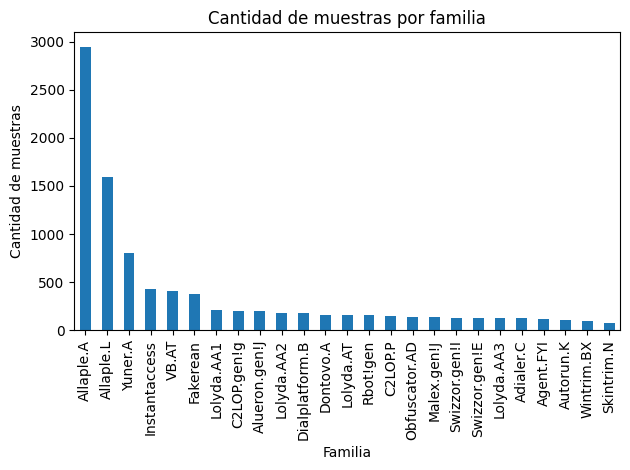

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("malimg_paper_dataset_imgs")

# Listar subdirectorios dentro del folder
familias = [p for p in base_path.iterdir() if p.is_dir()]

# Contar archivos por familia
conteo = {familia.name: len(list(familia.iterdir())) for familia in familias}

# Graficar
pd.Series(conteo).sort_values(ascending=False).plot(
    kind="bar", title="Cantidad de muestras por familia"
)

plt.xlabel("Familia")
plt.ylabel("Cantidad de muestras")
plt.tight_layout()
plt.show()


### 🧹 Filtrado de familias con pocas observaciones

In [3]:
# 📌 Umbral mínimo de imágenes por familia
umbral_minimo = 100

# Filtramos las familias que cumplen con el mínimo
familias_filtradas = [familia for familia, cantidad in conteo.items() if cantidad >= umbral_minimo]

print(f"Se conservarán {len(familias_filtradas)} familias:")
print(familias_filtradas)

Se conservarán 23 familias:
['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.gen!g', 'C2LOP.P', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Yuner.A']


Para mejorar el balance del dataset y evitar el sobreajuste, se excluyen las familias con menos de 100 imágenes.

## 🖼️ Visualización de imágenes

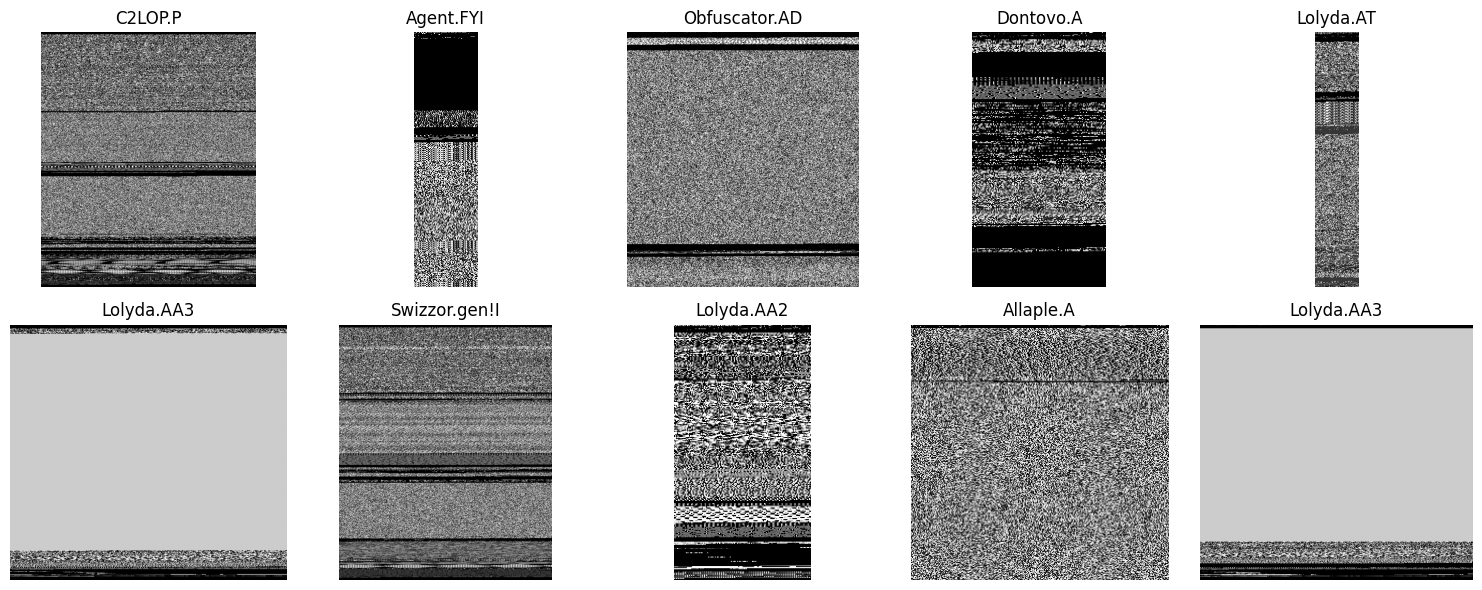

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from pathlib import Path

base_path = Path("malimg_paper_dataset_imgs")

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax in axs.flatten():
    familia = random.choice(familias_filtradas)
    familia_path = base_path / familia
    img_file = random.choice(list(familia_path.iterdir()))
    img = mpimg.imread(img_file)
    ax.imshow(img, cmap="gray")
    ax.set_title(familia)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 📦 Cargar imágenes (64x64, normalizadas):

In [5]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from pathlib import Path

# Dimensiones para redimensionar las imágenes
IMG_SIZE = (64, 64)

X = []
y = []

base_path = Path("malimg_paper_dataset_imgs")
label_map = {familia: idx for idx, familia in enumerate(familias_filtradas)}

for familia in familias_filtradas:
    carpeta = base_path / familia
    for archivo in carpeta.iterdir():
        try:
            # Cargar imagen en escala de grises, redimensionar
            imagen = load_img(archivo, color_mode='grayscale', target_size=IMG_SIZE)
            imagen_array = img_to_array(imagen) / 255.0  # Normalizar
            X.append(imagen_array)
            y.append(label_map[familia])
        except Exception as e:
            print(f"Error al procesar {archivo}: {e}")

X = np.array(X)
y = np.array(y)

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")


Shape de X: (9162, 64, 64, 1)
Shape de y: (9162,)


### División de datos (entrenamiento vs prueba)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (6413, 64, 64, 1), Test: (2749, 64, 64, 1)


### Construcción del modelo CNN con Keras

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(len(familias_filtradas), activation='softmax')  # Clasificación multiclase
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 12544)             0         
                                                                 
 dense (Dense)               (None, 128)               1

### entrenamiento del modelo

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)

Epoch 1/15
201/201 [==============================] - 11s 53ms/step - loss: 1.4284 - accuracy: 0.5615 - val_loss: 0.6787 - val_accuracy: 0.7137
Epoch 2/15
201/201 [==============================] - 10s 51ms/step - loss: 0.5951 - accuracy: 0.8263 - val_loss: 0.2764 - val_accuracy: 0.9323
Epoch 3/15
201/201 [==============================] - 10s 51ms/step - loss: 0.3756 - accuracy: 0.8885 - val_loss: 0.2572 - val_accuracy: 0.9309
Epoch 4/15
201/201 [==============================] - 10s 51ms/step - loss: 0.2946 - accuracy: 0.9127 - val_loss: 0.1566 - val_accuracy: 0.9473
Epoch 5/15
201/201 [==============================] - 9s 45ms/step - loss: 0.2285 - accuracy: 0.9284 - val_loss: 0.1545 - val_accuracy: 0.9473
Epoch 6/15
201/201 [==============================] - 10s 49ms/step - loss: 0.2094 - accuracy: 0.9340 - val_loss: 0.1456 - val_accuracy: 0.9516
Epoch 7/15
201/201 [==============================] - 10s 50ms/step - loss: 0.1881 - accuracy: 0.9397 - val_loss: 0.1400 - val_accuracy: 

### Gráficas de entrenamiento

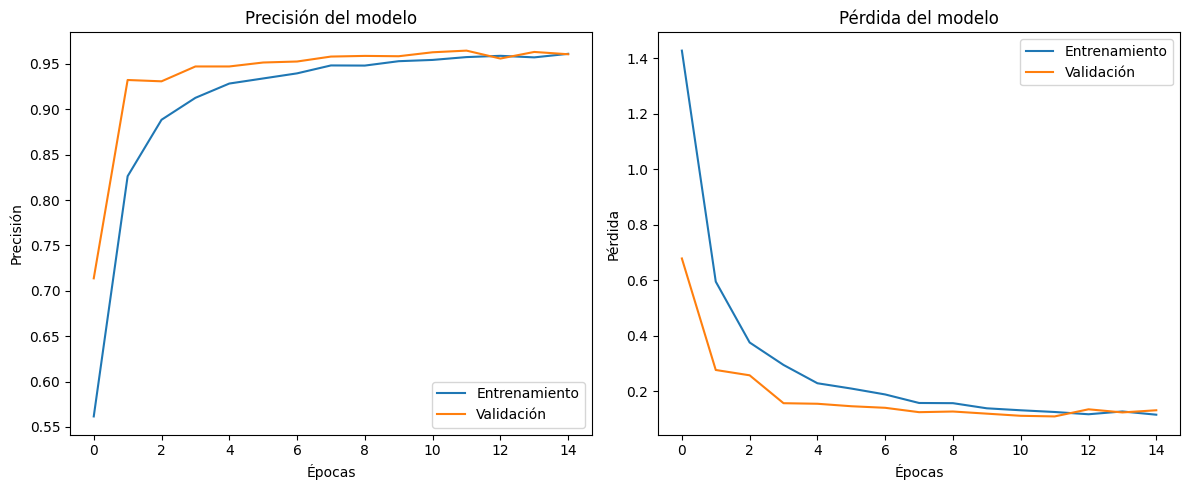

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

### Evaluación final y métricas

86/86 [==============================] - 1s 10ms/step - loss: 0.1311 - accuracy: 0.9607

🔍 Evaluación en test: accuracy = 0.9607, loss = 0.1311
86/86 [==============================] - 1s 10ms/step

📋 Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        35
           2       0.99      1.00      0.99       885
           3       1.00      1.00      1.00       477
           4       1.00      0.98      0.99        59
           5       0.00      0.00      0.00        32
           6       0.77      0.93      0.84        60
           7       0.89      0.77      0.83        44
           8       0.98      0.98      0.98        53
           9       1.00      1.00      1.00        49
          10       1.00      0.99      1.00       114
          11       1.00      1.00      1.00       129
          12       1.00      0.91      0.95        64
          13      

C:\Users\rebec\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rebec\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rebec\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

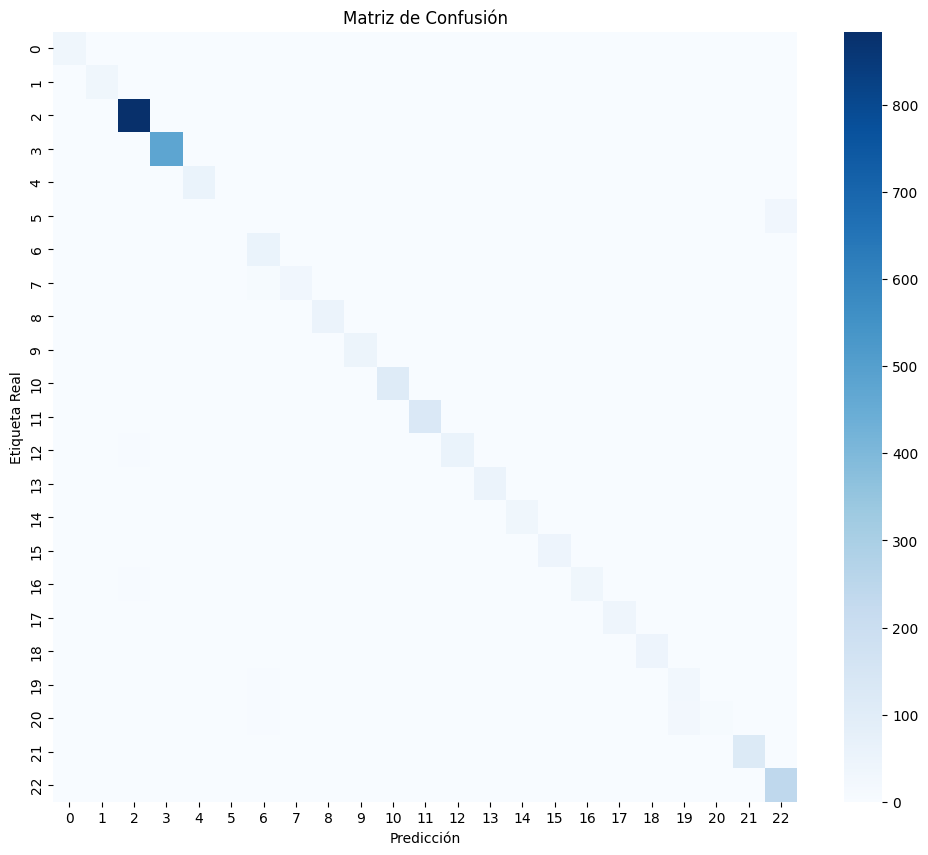

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluación en test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\n🔍 Evaluación en test: accuracy = {test_accuracy:.4f}, loss = {test_loss:.4f}")

# Reporte de clasificación
y_pred = np.argmax(model.predict(X_test), axis=1)
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=False, cmap="Blues", fmt='g')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.show()

La matriz de confusión muestra que el modelo logra una clasificación precisa para la mayoría de las familias de malware.  
Las predicciones correctas se alinean fuertemente con la diagonal, lo que indica buen rendimiento general.  
Algunas clases presentan leves confusiones, probablemente debido a similitudes visuales entre ciertas familias.

En general, la red neuronal convolucional demuestra ser efectiva para esta tarea de clasificación.

In [11]:
model.save("modelo_malware.h5")


C:\Users\rebec\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Lab 9 comienzo

In [12]:
import tensorflow as tf

# Desactiva eager execution
tf.compat.v1.disable_eager_execution()

#cargar el modelo y envolverlo con ART
from tensorflow.keras.models import load_model
from art.estimators.classification import KerasClassifier

model = load_model("modelo_malware.h5")
classifier = KerasClassifier(model=model, clip_values=(0.0, 1.0))


In [14]:
from art.attacks.evasion import FastGradientMethod

#Crear el ataque
attack_fgm = FastGradientMethod(estimator=classifier, eps=0.2)

#Generar muestras adversarias
X_test_adv_fgm = attack_fgm.generate(x=X_test)

#Predecir con el modelo sobre las muestras adversarias
preds_adv = classifier.predict(X_test_adv_fgm)

# 4. Evaluar precisión
acc_adv = np.sum(np.argmax(preds_adv, axis=1) == y_test) / y_test.shape[0]
print(f"Precisión bajo ataque FGM: {acc_adv:.4f}")


Precisión bajo ataque FGM: 0.0484


In [16]:
from art.attacks.evasion import ProjectedGradientDescent

# Crear el ataque
attack_pgd = ProjectedGradientDescent(estimator=classifier, eps=0.2, max_iter=40)

# Generar muestras adversarias
X_test_adv_pgd = attack_pgd.generate(x=X_test)

# Predecir
preds_adv_pgd = classifier.predict(X_test_adv_pgd)

#Evaluar precisión
acc_adv_pgd = np.sum(np.argmax(preds_adv_pgd, axis=1) == y_test) / y_test.shape[0]
print(f"🔥 Precisión bajo ataque PGD: {acc_adv_pgd:.4f}")


PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

...

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

🔥 Precisión bajo ataque PGD: 0.0040


### Parte 2

In [21]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from art.estimators.classification import KerasClassifier
from tensorflow.compat.v1.train import AdamOptimizer
from art.defences.trainer import AdversarialTrainerMadryPGD

# ⚠️ Asegúrate de haber desactivado eager execution en una celda anterior
tf.compat.v1.disable_eager_execution()  # ya hecho antes

# 1. Cargar el modelo
model = load_model("modelo_malware.h5")

# 2. Volver a compilar usando el optimizador compatible con Keras v1 API
model.compile(optimizer=AdamOptimizer(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# 3. Envolver nuevamente el modelo con ART
classifier = KerasClassifier(model=model, clip_values=(0, 1))

# 4. Entrenar el modelo con defensa adversaria
trainer = AdversarialTrainerMadryPGD(classifier=classifier, nb_epochs=10, batch_size=32, eps=0.2)
trainer.fit(X_train, y_train)


Precompute adv samples:   0%|          | 0/1 [00:00<?, ?it/s]

Adversarial training epochs:   0%|          | 0/10 [00:00<?, ?it/s]

In [22]:
# Eval en datos normales
pred_clean = classifier.predict(X_test)
acc_clean = np.sum(np.argmax(pred_clean, axis=1) == y_test) / y_test.shape[0]
print(f"✅ Precisión post-defensa (datos limpios): {acc_clean:.4f}")

# Eval contra ataque FGM
X_test_adv_defended = attack_fgm.generate(x=X_test)
pred_adv = classifier.predict(X_test_adv_defended)
acc_adv = np.sum(np.argmax(pred_adv, axis=1) == y_test) / y_test.shape[0]
print(f"🛡️ Precisión post-defensa (FGM): {acc_adv:.4f}")

# Eval contra ataque PGD (opcional)
X_test_adv_pgd_defended = attack_pgd.generate(x=X_test)
pred_adv_pgd = classifier.predict(X_test_adv_pgd_defended)
acc_adv_pgd = np.sum(np.argmax(pred_adv_pgd, axis=1) == y_test) / y_test.shape[0]
print(f"🛡️ Precisión post-defensa (PGD): {acc_adv_pgd:.4f}")


✅ Precisión post-defensa (datos limpios): 0.7115
🛡️ Precisión post-defensa (FGM): 0.6948


PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

...

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

PGD - Random Initializations:   0%|          | 0/1 [00:00<?, ?it/s]

PGD - Iterations:   0%|          | 0/40 [00:00<?, ?it/s]

🛡️ Precisión post-defensa (PGD): 0.6988


In [23]:
import pandas as pd

# Resultados antes y después de la defensa
resultados = {
    "Condición": ["Datos limpios", "FGM (ε=0.2)", "PGD (ε=0.2)"],
    "Precisión antes": ["—", 0.0484, 0.0040],
    "Precisión después": [0.7115, 0.6948, 0.6988]
}

df_resultados = pd.DataFrame(resultados)
display(df_resultados)


,Condición,Precisión antes,Precisión después
0,Datos limpios,—,0.7115
1,FGM (ε=0.2),0.0484,0.6948
2,PGD (ε=0.2),0.004,0.6988


#### Ataques

Fast Gradient Method (FGM)

El ataque FGM es un método de evasión basdo en gradientes. Es rápido y eficiente pero menos potente. Este ataque busca encontrar una pequeña modificación imperceptible en los datos par engañar al modelo y así clasifique incorrectamente, explotando su sensibilidad a pequeñas variaciones.

En el laboratorio configuramos FGM con un valor de 0.2 el cual es el que determina la perturbación. Este ataque se aplica sobre X_test usando el modelo entrenado anteriormente y vemos como la presición del modelo se redujo a 4.8% lo cual nos muestra su vulnerabilidad



Projected Gradient Descent (PGD)

PGD es una extensión de FGM y es uno de los ataques más fuertes. Tiene diferentes pasos de perturbación. PGD ajusta la entrada varias veces para generar ejemplos adversarios más efectivos lo cual es idal para pruebas de robustez

En PGD también usamos 0.2 y 40 iteraciones. Este ataque fue aún más eficiente que FG ya que la presición bajó a un 0.4% y muestra la debilidad a estas amenazas

#### Defensa

Adversarial Training con PGD

Es una técnica de defensa en la que el modelo se entrena con datos limpios y ejemplos generaods en tiempo real por medio de ataques como PGD. De esta manera, el modelo aprende a reconocer y resisitir. Esta defensa hace que el modelo sea más tolerante a pequeñas perturbaciones.

Lo aplicamos a nuestro codigo usando ataques PGD durante el entrenamiento. Este se entrenó por 10 épocas con diferentes ejemplos y adversarios. Se fortaleció el modelo sin tener que modificar la arquitectura orifinal.

#### Resultados
Después del entrenamiento adversario, evaluamos el modelo con los mismos ataques usados anteriormente. Los resultados fueron significativamente mejores:

    Con FGM, la precisión aumentó de 4.8% a 69.5%.

    Con PGD, la precisión pasó de 0.4% a 69.9%.

    En datos normales (sin ataque), el modelo logró una precisión del 71.1%.

Esto demuestra que el modelo adquirió una robustez considerable ante ejemplos adversarios, lo que valida la efectividad de la defensa implementada.
